In [1]:
import sys
import subprocess

print("Εγκατάσταση σταθερών εκδόσεων βιβλιοθηκών.")
result = subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "transformers==4.44.0", "datasets", "accelerate", "scikit-learn",
    "sentencepiece", "protobuf", "spacy"], capture_output=True, text=True)

import transformers
print(f"Transformers version: {transformers.__version__}")

assert transformers.__version__.startswith("4.44"), \
    f"STOP: Η έκδοση είναι {transformers.__version__}. Κάνε Restart το Session/Kernel και ξανατρέξε αυτό το κελί."

print("Όλες οι βιβλιοθήκες εγκαταστάθηκαν σωστά.")

Εγκατάσταση σταθερών εκδόσεων βιβλιοθηκών.
Transformers version: 4.44.0
Όλες οι βιβλιοθήκες εγκαταστάθηκαν σωστά.


In [2]:
!pip install optuna
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import os
!pip install sentencepiece
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from collections import Counter
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from transformers import DistilBertConfig, DistilBertForSequenceClassification
from transformers.optimization import Adafactor
from sklearn.metrics import f1_score
import numpy as np
import random
import optuna
from optuna.samplers import TPESampler
import torch.nn.functional as F
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


def set_seed(seed_value=42):
    os.environ['PYTHONHASHSEED']=str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
        torch.use_deterministic_algorithms(True, warn_only=True)



set_seed(42)
dataset = load_dataset("ailsntua/QEvasion")
print("Dataset structure:")
print(dataset)
print("-" * 50)

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])
train_df.head()

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df['clarity_label']
)

print(f"Training Set new size: {len(train_df)}")
print(f"Validation Set size: {len(val_df)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 308
    })
})
--------------------------------------------------
Training Set new size: 2758
Validation Set size: 690


In [3]:
train_duplicates = train_df.duplicated(subset=['question', 'interview_answer']).sum()
if train_duplicates > 0:
    train_df = train_df.drop_duplicates(subset=['question', 'interview_answer'])
    print(f"Dropped {train_duplicates} duplicates from Training Set.")

val_duplicates = val_df.duplicated(subset=['question', 'interview_answer']).sum()
if val_duplicates > 0:
    val_df = val_df.drop_duplicates(subset=['question', 'interview_answer'])
    print(f"Dropped {val_duplicates} duplicates from Validation Set.")

val_size_before = len(val_df)
val_df = val_df[~val_df.set_index(['question', 'interview_answer']).index.isin(
    train_df.set_index(['question', 'interview_answer']).index
)]
leakage_count = val_size_before - len(val_df)
print(f"- {leakage_count} instances dropped from Validation set (already existed in Training set).")
print(f"- Training Set final size: {len(train_df)}")
print(f"- Validation Set final size: {len(val_df)}")

Dropped 34 duplicates from Training Set.
Dropped 3 duplicates from Validation Set.
- 21 instances dropped from Validation set (already existed in Training set).
- Training Set final size: 2724
- Validation Set final size: 666


In [4]:
print("Unique clarity labels:", train_df['clarity_label'].unique())

label_mapping = {"Clear Reply": 0, "Ambivalent": 1, "Clear Non-Reply": 2}

train_df['label'] = train_df['clarity_label'].map(label_mapping)
val_df['label'] = val_df['clarity_label'].map(label_mapping)

print(f"NaN in Train: {train_df['label'].isnull().sum()}")
print(f"NaN in Val: {val_df['label'].isnull().sum()}")

print("\n" + "="*50)
print("SAMPLE QUESTION FROM TRAINING SET:")
print(train_df['question'].iloc[0])
print("-" * 50)
print("SAMPLE ANSWER:")
print(train_df['interview_answer'].iloc[0])
print("-" * 50)
print("LABEL (Word):", train_df['clarity_label'].iloc[0])
print("LABEL (Number):", train_df['label'].iloc[0])
print("="*50)

Unique clarity labels: ['Clear Non-Reply' 'Clear Reply' 'Ambivalent']
NaN in Train: 0
NaN in Val: 0

SAMPLE QUESTION FROM TRAINING SET:
 Possible discussions about inspections to North Korea's nuclear sites during negotiations.
--------------------------------------------------
SAMPLE ANSWER:
You're going to have to speak a little louder. And where are you from? Where are you from?
--------------------------------------------------
LABEL (Word): Clear Non-Reply
LABEL (Number): 2


Class Distribution:
clarity_label
Ambivalent         1607
Clear Reply         836
Clear Non-Reply     281
Name: count, dtype: int64

Percentages:
clarity_label
Ambivalent         58.99%
Clear Reply        30.69%
Clear Non-Reply    10.32%
Name: count, dtype: object


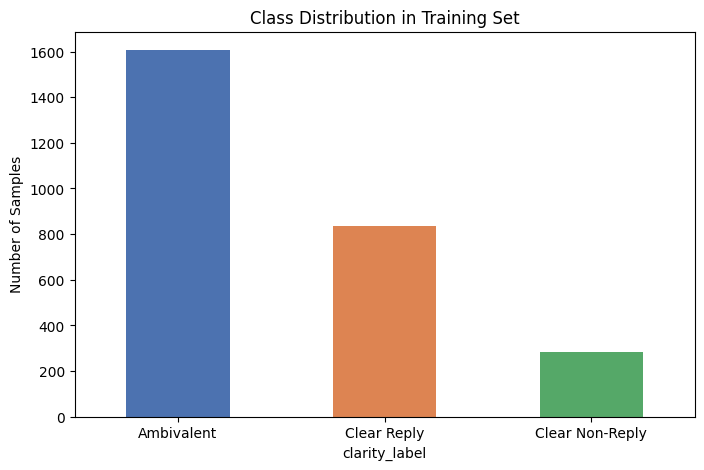

In [5]:
print("Class Distribution:")
class_counts = train_df['clarity_label'].value_counts()
print(class_counts)

percentages = (class_counts / len(train_df)) * 100
print("\nPercentages:")
print(percentages.round(2).astype(str) + "%")

class_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'], figsize=(8,5))
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [6]:
label_mapping = {"Clear Reply": 0, "Ambivalent": 1, "Clear Non-Reply": 2}

for df in [train_df, val_df]:
    df['label'] = df['clarity_label'].map(label_mapping)
    df.dropna(subset=['question', 'interview_answer', 'label'], inplace=True)
    df.reset_index(drop=True, inplace=True)

test_df['label'] = test_df['clarity_label'].map(label_mapping)
test_df['question'] = test_df['question'].fillna("")
test_df['interview_answer'] = test_df['interview_answer'].fillna("")

print("Searching for Missing Values in Training:")
print(train_df[['question', 'interview_answer', 'label']].isnull().sum())

print("-" * 30)
print(f"Final Train size: {len(train_df)}")
print(f"Final Val size: {len(val_df)}")
print(f"Final Test size: {len(test_df)}")

Searching for Missing Values in Training:
question            0
interview_answer    0
label               0
dtype: int64
------------------------------
Final Train size: 2724
Final Val size: 666
Final Test size: 308


In [7]:
class ClarityDataset(Dataset):
    def __init__(self, questions, answers, labels, tokenizer, max_len):
        self.questions = questions
        self.answers = answers
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, item):
        question = str(self.questions[item])
        answer = str(self.answers[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            question,
            answer,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
MAX_LEN = 256
BATCH_SIZE = 8

train_dataset = ClarityDataset(
    questions=train_df['question'].to_numpy(),
    answers=train_df['interview_answer'].to_numpy(),
    labels=train_df['label'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

val_dataset = ClarityDataset(
    questions=val_df['question'].to_numpy(),
    answers=val_df['interview_answer'].to_numpy(),
    labels=val_df['label'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

test_dataset = ClarityDataset(
    questions=test_df['question'].to_numpy(),
    answers=test_df['interview_answer'].to_numpy(),
    labels=test_df['label'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)


g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


DataLoaders ready. Train batches: 341, Val batches: 84, Test batches: 39


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

model_name = "microsoft/deberta-v3-base"
set_seed(42)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3 # 0: Clear Reply, 1: Ambivalent, 2: Clear Non-Reply
)
model.to(device)

labels = train_df['label'].tolist()
counts = Counter(labels)
total = sum(counts.values())
weights = [total / counts[i] for i in range(3)]
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print("The model has loaded.")
print("Implemented Class Weights:")
print(f"- Clear Reply (0): {weights[0]:.2f}")
print(f"- Ambivalent (1): {weights[1]:.2f}")
print(f"- Clear Non-Reply (2): {weights[2]:.2f}")

Using: cuda


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


The model has loaded.
Implemented Class Weights:
- Clear Reply (0): 3.26
- Ambivalent (1): 1.70
- Clear Non-Reply (2): 9.69


Σε αυτό το βήμα, δημιουργούμε έναν βασικό βρόχο εκπαίδευσης (training loop) για να τρέξουμε το Deberta με παραμέτρους LR=2e-5 και Batch=8, αποκτώντας έτσι ένα αρχικό F1-Score ως σημείο αναφοράς.

In [9]:
optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 3
best_f1 = 0.0
best_epoch = 0

print(f"Starting Training on {device}...\n")

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for batch in train_loop:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        for batch in val_loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_val_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    current_f1 = f1_score(all_labels, all_preds, average='macro')
    val_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean()

    print(f"\nEnd of Epoch {epoch+1}:")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2%} | Val F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"New Best Model saved with Macro F1: {best_f1:.4f}")

    print("-" * 50)

print(f"\nFine-tuning completed.")
print(f"The best model was found at Epoch {best_epoch} with Validation Macro F1 Score: {best_f1:.2%}")


Starting Training on cuda...



Epoch 1/3 [Train]: 100%|██████████| 341/341 [06:13<00:00,  1.09s/it, loss=0.946]



End of Epoch 1:
Train Loss: 1.0768 | Val Loss: 1.0485 | Val Acc: 28.98% | Val F1: 0.2535
New Best Model saved with Macro F1: 0.2535
--------------------------------------------------


Epoch 2/3 [Train]: 100%|██████████| 341/341 [06:14<00:00,  1.10s/it, loss=1.07]



End of Epoch 2:
Train Loss: 1.0558 | Val Loss: 1.0349 | Val Acc: 54.80% | Val F1: 0.3473
New Best Model saved with Macro F1: 0.3473
--------------------------------------------------


Epoch 3/3 [Train]: 100%|██████████| 341/341 [06:13<00:00,  1.10s/it, loss=0.856]
                                                                


End of Epoch 3:
Train Loss: 1.0412 | Val Loss: 1.0347 | Val Acc: 53.30% | Val F1: 0.3430
--------------------------------------------------

Fine-tuning completed.
The best model was found at Epoch 2 with Validation Macro F1 Score: 34.73%


Έχοντας το Baseline, παρατηρήσαμε την ανάγκη για πειραματισμό με τις παραμέτρους (π.χ. για τη μείωση του overfitting). Για να γίνει αυτό συστηματικά και καθαρά, ενσωματώνουμε τη διαδικασία εκπαίδευσης σε μια γενική συνάρτηση run_experiment

In [10]:
def run_experiment(train_dataset, val_dataset, batch_size=8, lr=1e-5,
                   weight_decay=0.01, dropout=0.1, optimizer_type='adamw',
                   epochs=3, save_path=None, model_name='microsoft/deberta-v3-base'):

    set_seed(42)

    g = torch.Generator()
    g.manual_seed(42)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    config = AutoConfig.from_pretrained(model_name,
                                        hidden_dropout_prob=dropout,
                                        classifier_dropout=dropout,
                                        num_labels=3)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config).to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=g)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    if optimizer_type.lower() == 'adafactor':
        optimizer = Adafactor(model.parameters(), lr=lr, weight_decay=weight_decay, scale_parameter=False, relative_step=False)
    else:
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_f1 = 0.0

    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        total_train_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # VALIDATION PHASE
        model.eval()
        total_val_loss = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)

                loss = loss_fn(outputs.logits, labels)
                total_val_loss += loss.item()

                preds = torch.argmax(outputs.logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        current_f1 = f1_score(all_labels, all_preds, average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(current_f1)

        if current_f1 > best_f1:
            best_f1 = current_f1
            if save_path:
                torch.save(model.state_dict(), save_path)

    return best_f1, history

In [11]:
from transformers import AutoConfig

In [12]:
# Πείραμα Α: Αύξηση Regularization (Καταπολέμηση Overfitting)
print("Πείραμα Α")
set_seed(42)
f1_exp_a, _ = run_experiment(
    train_dataset,
    val_dataset,
    lr=2e-5,
    batch_size=8,
    weight_decay=0.1,  # Από 0.01 πήγε 0.1
    dropout=0.2,       # Από 0.1 πήγε 0.2
    epochs=3
)

print(f"Τελικό Validation Macro F1: {f1_exp_a:.4f}")

Πείραμα Α


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 3 [Train]: 100%|██████████| 341/341 [06:14<00:00,  1.10s/it]


Τελικό Validation Macro F1: 0.3564


In [13]:
# Πείραμα Β: Μεγαλύτερο Learning Rate, Λιγότερες Εποχές
print("Πείραμα Β")
set_seed(42)
f1_exp_b, _ = run_experiment(
    train_dataset,
    val_dataset,
    lr=2e-5,           # Αυξήσαμε το LR
    batch_size=8,
    weight_decay=0.01, # Επαναφορά στο κανονικό
    dropout=0.1,
    epochs=2           # Μειώσαμε τις εποχές
)

print(f"Τελικό Validation Macro F1: {f1_exp_b:.4f}")

Πείραμα Β


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 2 [Train]: 100%|██████████| 341/341 [06:13<00:00,  1.10s/it]


Τελικό Validation Macro F1: 0.3473


In [14]:
# Πείραμα Γ: Αλλαγή Batch Size
print("Πείραμα Γ - Αλλαγή Batch size")

print("Μεγαλώνοντας το batch size παίρνουμε Out Of Memory error, ενώ, μειώνοντάς το, καθηστερούμε υπερβολικά την εκπαίδευση και ρισκάρουμε να μην βρεθεί το καλύτερο F1 Score.")

Πείραμα Γ - Αλλαγή Batch size
Μεγαλώνοντας το batch size παίρνουμε Out Of Memory error, ενώ, μειώνοντάς το, καθηστερούμε υπερβολικά την εκπαίδευση και ρισκάρουμε να μην βρεθεί το καλύτερο F1 Score.


In [15]:
# Πείραμα Δ: Αλλαγή Optimizer σε Adafactor
set_seed(42)
print("Πείραμα Δ")
f1_exp_d, _ = run_experiment(
    train_dataset, val_dataset,
    lr=2e-5,
    batch_size=8,
    weight_decay=0.01,
    optimizer_type='adafactor',
    epochs=3
)

print(f"Τελικό Validation Macro F1: {f1_exp_d:.4f}")

Πείραμα Δ


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 3 [Train]: 100%|██████████| 341/341 [06:19<00:00,  1.11s/it]


Τελικό Validation Macro F1: 0.5643


In [16]:
# Πείραμα Ε: Αύξηση  Max Sequence Length (512)
set_seed(42)
print("Προετοιμασία Πειράματος Ε")

train_dataset_256 = ClarityDataset(
    questions=train_df['question'].to_numpy(),
    answers=train_df['interview_answer'].to_numpy(),
    labels=train_df['label'].to_numpy(),
    tokenizer=tokenizer,
    max_len=256
)

val_dataset_256 = ClarityDataset(
    questions=val_df['question'].to_numpy(),
    answers=val_df['interview_answer'].to_numpy(),
    labels=val_df['label'].to_numpy(),
    tokenizer=tokenizer,
    max_len=256
)

train_dataset_512 = ClarityDataset(
    questions=train_df['question'].to_numpy(),
    answers=train_df['interview_answer'].to_numpy(),
    labels=train_df['label'].to_numpy(),
    tokenizer=tokenizer,
    max_len=512
)

val_dataset_512 = ClarityDataset(
    questions=val_df['question'].to_numpy(),
    answers=val_df['interview_answer'].to_numpy(),
    labels=val_df['label'].to_numpy(),
    tokenizer=tokenizer,
    max_len=512
)

print("Πείραμα Ε")
f1_exp_e, final_history = run_experiment(
    train_dataset_512,
    val_dataset_512,
    lr=2e-5,
    batch_size=8,
    epochs=3,
    save_path='best_model_deberta_final.pt'
)
    
print(f"Τελικό Validation Macro F1: {f1_exp_e:.4f}")

print("\n" + "="*50)
print(f"Η τελική εκπαίδευση ολοκληρώθηκε!")
print("Το αρχείο 'best_model_deberta_final.pt' είναι έτοιμο.")
print("="*50)

Προετοιμασία Πειράματος Ε
Πείραμα Ε


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 3 [Train]: 100%|██████████| 341/341 [19:10<00:00,  3.37s/it]


Τελικό Validation Macro F1: 0.5953

Η τελική εκπαίδευση ολοκληρώθηκε!
Το αρχείο 'best_model_deberta_final.pt' είναι έτοιμο.


In [17]:
import gc

print("Καθαρισμός μνήμης πριν το Optuna.")

gc.collect()

torch.cuda.empty_cache()

print("Η μνήμη καθάρισε. Έτοιμοι για το Optuna.")

Καθαρισμός μνήμης πριν το Optuna.
Η μνήμη καθάρισε. Έτοιμοι για το Optuna.


In [18]:
# Hyperparameter Tuning με Optuna (Πείραμα Ζ - Deberta)
print("Optuna Study (Πείραμα Ζ - Deberta)")
set_seed(42)
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 4e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 0.01, 0.1)
    dropout = trial.suggest_float("dropout", 0.1, 0.3)

    current_batch_size = 8

    print(f"Δοκιμή Optuna: LR={lr:.5f}, WD={weight_decay:.3f}, Dropout={dropout:.2f} (Batch={current_batch_size})")

    # Εκτέλεση Πειράματος
    best_f1, _ = run_experiment(
        train_dataset=train_dataset_256, #Το 512 έβγαζε out of memory error
        val_dataset=val_dataset_256,
        lr=lr,
        batch_size=current_batch_size,
        dropout=dropout,
        weight_decay=weight_decay,
        epochs=3
    )
    gc.collect()
    torch.cuda.empty_cache()

    return best_f1

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=5)

print("\n" + "="*50)
print(f"Το Καλύτερο Μοντέλο πέτυχε F1: {study.best_value:.4f}")
print("Οι τέλειες παράμετροι ήταν:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")
print("="*50)

[I 2026-04-29 17:17:28,387] A new study created in memory with name: no-name-d1bba75f-4903-4d0a-be57-bb692de21b26


Optuna Study (Πείραμα Ζ - Deberta)
Δοκιμή Optuna: LR=0.00002, WD=0.096, Dropout=0.25 (Batch=8)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 3 [Train]: 100%|██████████| 341/341 [06:14<00:00,  1.10s/it]
[I 2026-04-29 17:36:59,628] Trial 0 finished with value: 0.34891550040879143 and parameters: {'lr': 1.680720977739037e-05, 'weight_decay': 0.09556428757689246, 'dropout': 0.24639878836228102}. Best is trial 0 with value: 0.34891550040879143.


Δοκιμή Optuna: LR=0.00002, WD=0.024, Dropout=0.13 (Batch=8)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 3 [Train]: 100%|██████████| 341/341 [06:14<00:00,  1.10s/it]
[I 2026-04-29 17:56:30,066] Trial 1 finished with value: 0.3469123138791097 and parameters: {'lr': 2.2931281295479732e-05, 'weight_decay': 0.02404167763981929, 'dropout': 0.13119890406724052}. Best is trial 0 with value: 0.34891550040879143.


...

Δοκιμή Optuna: LR=0.00003, WD=0.012, Dropout=0.29 (Batch=8)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 3 [Train]: 100%|██████████| 341/341 [06:14<00:00,  1.10s/it]
[I 2026-04-29 18:35:30,660] Trial 3 finished with value: 0.5495607046353315 and parameters: {'lr': 2.6687148364280124e-05, 'weight_decay': 0.011852604486622221, 'dropout': 0.2939819704323988}. Best is trial 3 with value: 0.5495607046353315.


Δοκιμή Optuna: LR=0.00003, WD=0.029, Dropout=0.14 (Batch=8)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 3 [Train]: 100%|██████████| 341/341 [06:14<00:00,  1.10s/it]
[I 2026-04-29 18:55:00,426] Trial 4 finished with value: 0.41990765278683434 and parameters: {'lr': 3.17088439804208e-05, 'weight_decay': 0.029110519961044856, 'dropout': 0.1363649934414201}. Best is trial 3 with value: 0.5495607046353315.



Το Καλύτερο Μοντέλο πέτυχε F1: 0.5496
Οι τέλειες παράμετροι ήταν:
  - lr: 2.6687148364280124e-05
  - weight_decay: 0.011852604486622221
  - dropout: 0.2939819704323988


In [19]:
print("Καθαρισμός μνήμης μετά το Optuna.")

gc.collect()

torch.cuda.empty_cache()

print("Η μνήμη καθάρισε.")

Καθαρισμός μνήμης μετά το Optuna.
Η μνήμη καθάρισε.


In [20]:
# 1. Φόρτωση του Καλύτερου Μοντέλου (Από το Πείραμα Ε)
set_seed(42)

config = AutoConfig.from_pretrained(
    'microsoft/deberta-v3-base',
    num_labels=3
)

best_model = AutoModelForSequenceClassification.from_pretrained('microsoft/deberta-v3-base', config=config)

best_model.load_state_dict(torch.load('best_model_deberta_final.pt'))
best_model.to(device)
best_model.eval()

print("Τα βάρη του καλύτερου μοντέλου φορτώθηκαν επιτυχώς.")

from torch.utils.data import DataLoader

val_loader_final = DataLoader(val_dataset_512, batch_size=8, shuffle=False)

print("Ο val_loader είναι έτοιμος.")

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Τα βάρη του καλύτερου μοντέλου φορτώθηκαν επιτυχώς.
Ο val_loader είναι έτοιμος.


In [21]:
batch = next(iter(val_loader_final))
input_ids = batch['input_ids'].to(device)[:5]
attention_mask = batch['attention_mask'].to(device)[:5]
true_labels = batch['labels'].to(device)[:5]

with torch.no_grad():
    outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits
    probabilities = F.softmax(logits, dim=1)

labels_map = {0: "Clear Reply", 1: "Ambivalent", 2: "Clear Non-Reply"}

print("Analysis:")

for i in range(5):
    print(f"\nΔείγμα {i+1}:")
    print(f"Πραγματική Κατηγορία: {labels_map[true_labels[i].item()]}")

    probs = probabilities[i].cpu().numpy() * 100

    print(f"Πιθανότητες Μοντέλου:")
    print(f"- Clear Reply (0):     {probs[0]:.2f}%")
    print(f"- Ambivalent (1):      {probs[1]:.2f}%")
    print(f"- Clear Non-Reply (2): {probs[2]:.2f}%")

    predicted_class = torch.argmax(probabilities[i]).item()


    if predicted_class == true_labels[i].item():
        status = "ΣΩΣΤΟ"
    else:
        status = "ΛΑΘΟΣ"

    print(f"Τελική Απόφαση Μοντέλου: {labels_map[predicted_class]} {status}")

Analysis:

Δείγμα 1:
Πραγματική Κατηγορία: Ambivalent
Πιθανότητες Μοντέλου:
- Clear Reply (0):     49.51%
- Ambivalent (1):      47.23%
- Clear Non-Reply (2): 3.26%
Τελική Απόφαση Μοντέλου: Clear Reply ΛΑΘΟΣ

Δείγμα 2:
Πραγματική Κατηγορία: Clear Reply
Πιθανότητες Μοντέλου:
- Clear Reply (0):     37.23%
- Ambivalent (1):      57.70%
- Clear Non-Reply (2): 5.07%
Τελική Απόφαση Μοντέλου: Ambivalent ΛΑΘΟΣ

Δείγμα 3:
Πραγματική Κατηγορία: Ambivalent
Πιθανότητες Μοντέλου:
- Clear Reply (0):     44.15%
- Ambivalent (1):      51.87%
- Clear Non-Reply (2): 3.98%
Τελική Απόφαση Μοντέλου: Ambivalent ΣΩΣΤΟ

Δείγμα 4:
Πραγματική Κατηγορία: Clear Reply
Πιθανότητες Μοντέλου:
- Clear Reply (0):     40.13%
- Ambivalent (1):      55.91%
- Clear Non-Reply (2): 3.96%
Τελική Απόφαση Μοντέλου: Ambivalent ΛΑΘΟΣ

Δείγμα 5:
Πραγματική Κατηγορία: Clear Reply
Πιθανότητες Μοντέλου:
- Clear Reply (0):     80.41%
- Ambivalent (1):      17.35%
- Clear Non-Reply (2): 2.24%
Τελική Απόφαση Μοντέλου: Clear Reply ΣΩΣΤΟ


In [22]:
all_preds = []
all_labels = []

print("Evaluating on Validation Set (with Final Best Model).")

with torch.no_grad():
    for batch in tqdm(val_loader_final, desc="Validating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = ['Clear Reply (0)', 'Ambivalent (1)', 'Clear Non-Reply (2)']

report_dict = classification_report(all_labels, all_preds, target_names=target_names, output_dict=True)

print("\n" + "="*50)
print("VALIDATION SET FINAL METRICS (FINAL BEST MODEL)")
print("="*50)

print(f"Συνολικό Accuracy : {report_dict['accuracy']:.4f}")
print(f"Weighted F1-Score : {report_dict['weighted avg']['f1-score']:.4f}")
print(f"Macro F1-Score    : {report_dict['macro avg']['f1-score']:.4f}")
print("-" * 50)

print("Αναλυτικά ανά κατηγορία:\n")
for category in target_names:
    metrics = report_dict[category]
    print(f"[{category}]")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1-Score  : {metrics['f1-score']:.4f}")
    print()
print("="*50)

Evaluating on Validation Set (with Final Best Model).


Validating: 100%|██████████| 84/84 [00:34<00:00,  2.44it/s]


VALIDATION SET FINAL METRICS (FINAL BEST MODEL)
Συνολικό Accuracy : 0.6366
Weighted F1-Score : 0.6304
Macro F1-Score    : 0.5953
--------------------------------------------------
Αναλυτικά ανά κατηγορία:

[Clear Reply (0)]
  Precision : 0.5570
  Recall    : 0.4109
  F1-Score  : 0.4729

[Ambivalent (1)]
  Precision : 0.7042
  Recall    : 0.7310
  F1-Score  : 0.7173

[Clear Non-Reply (2)]
  Precision : 0.4907
  Recall    : 0.7571
  F1-Score  : 0.5955



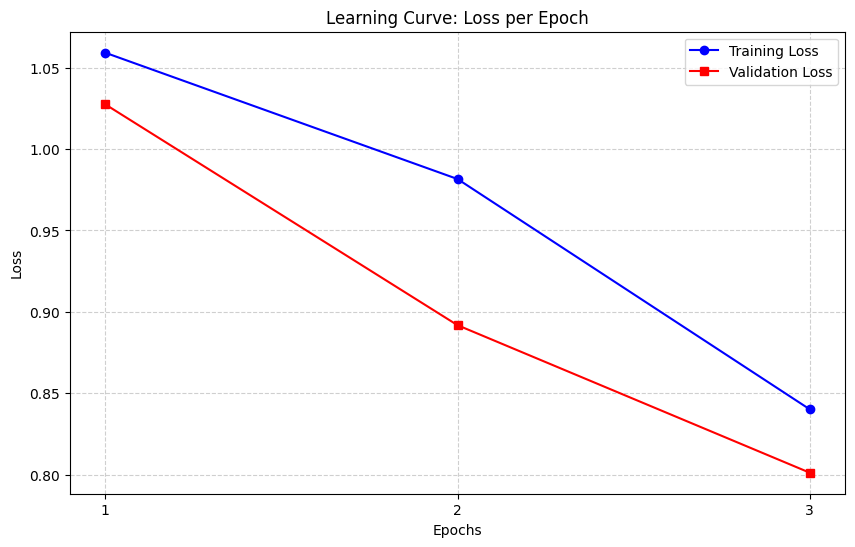

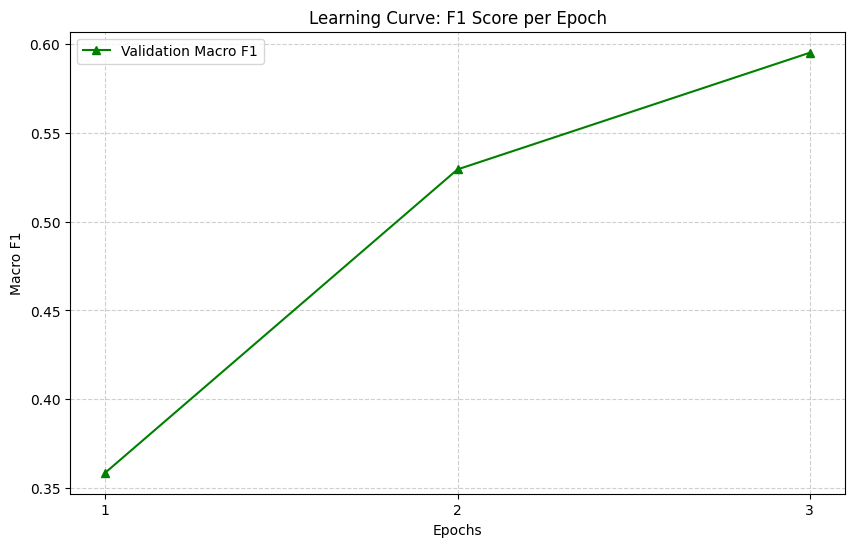

In [23]:
import matplotlib.pyplot as plt

# ΓΡΑΦΗΜΑ LEARNING CURVE (LOSS)
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(final_history['train_loss']) + 1)

plt.plot(epochs_range, final_history['train_loss'], 'b-o', label='Training Loss')
plt.plot(epochs_range, final_history['val_loss'], 'r-s', label='Validation Loss')

plt.title('Learning Curve: Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('Learning_Curve:_Loss_per_Epoch.png', dpi=300, bbox_inches='tight')
plt.show()

# ΓΡΑΦΗΜΑ F1-SCORE
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, final_history['val_f1'], 'g-^', label='Validation Macro F1')
plt.title('Learning Curve: F1 Score per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Macro F1')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('Learning_Curve:_F1_Score_per_Epoch.png', dpi=300, bbox_inches='tight')
plt.show()

Εξαγωγή δεδομένων από το καλύτερο μοντέλο.


Generating plots: 100%|██████████| 84/84 [00:34<00:00,  2.44it/s]


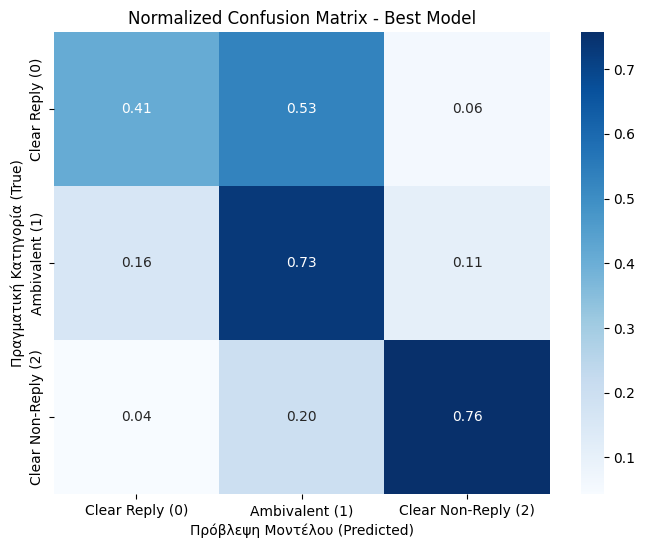

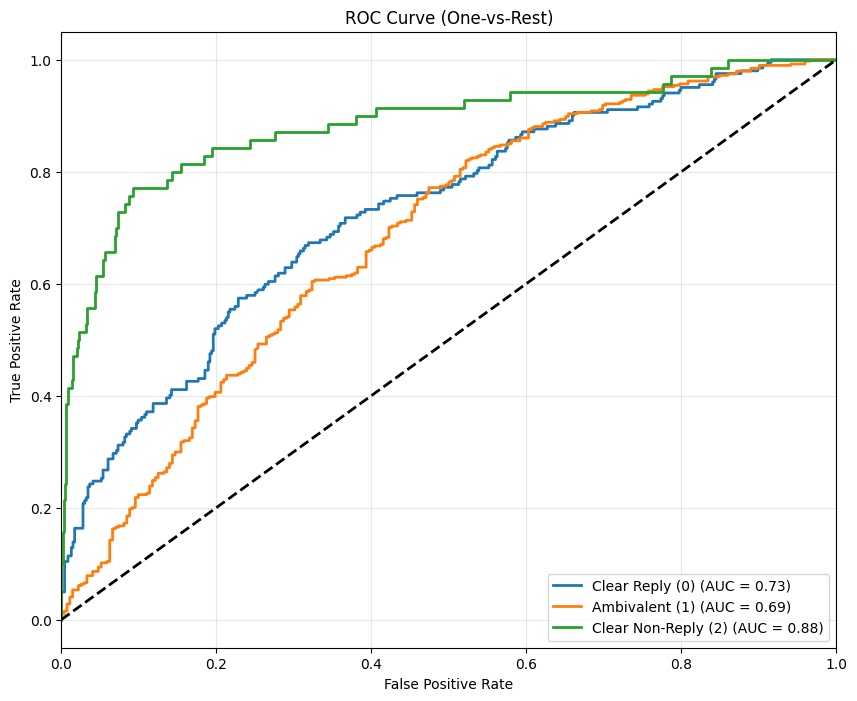

In [24]:
all_preds = []
all_labels = []
all_probs = []

print("Εξαγωγή δεδομένων από το καλύτερο μοντέλο.")
best_model.eval()
with torch.no_grad():

    for batch in tqdm(val_loader_final, desc="Generating plots"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)

        probs = F.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
target_names = ['Clear Reply (0)', 'Ambivalent (1)', 'Clear Non-Reply (2)']

# CONFUSION MATRIX
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_labels, all_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Πραγματική Κατηγορία (True)')
plt.xlabel('Πρόβλεψη Μοντέλου (Predicted)')
plt.title('Normalized Confusion Matrix - Best Model')
plt.savefig('Normalized_Confusion_Matrix_Best_Model.png', dpi=300, bbox_inches='tight')
plt.show()

# MULTI-CLASS ROC CURVE
y_bin = label_binarize(all_labels, classes=[0, 1, 2])
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(10, 8))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{target_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.savefig('ROC_Curve_One_vs_Rest.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
analysis_df = pd.DataFrame({
    'Question': val_df['question'].values,
    'Answer': val_df['interview_answer'].values,
    'True_Label': all_labels,
    'Predicted_Label': all_preds
})

label_map = {0: 'Clear Reply', 1: 'Ambivalent', 2: 'Clear Non-Reply'}
analysis_df['True_Label_Name'] = analysis_df['True_Label'].map(label_map)
analysis_df['Predicted_Label_Name'] = analysis_df['Predicted_Label'].map(label_map)

errors_df = analysis_df[analysis_df['True_Label'] != analysis_df['Predicted_Label']]

errors_filename = 'deberta_error_analysis.csv'
errors_df.to_csv(errors_filename, index=False)

print(f"Βρέθηκαν {len(errors_df)} λανθασμένες προβλέψεις.")
print(f"Το αρχείο {errors_filename} αποθηκεύτηκε στα Outputs.")
display(errors_df[['Question', 'Answer', 'True_Label_Name', 'Predicted_Label_Name']].head())

Βρέθηκαν 242 λανθασμένες προβλέψεις.
Το αρχείο deberta_error_analysis.csv αποθηκεύτηκε στα Outputs.


,Question,Answer,True_Label_Name,Predicted_Label_Name
0,What is the reason for the President's new ref...,"Well, no, Major, I think if you look at the hi...",Ambivalent,Clear Reply
1,Q. Do you believe that the United States shoul...,"With respect to Kashmir, obviously, this is a ...",Clear Reply,Ambivalent
3,Where is your line in the sand?,"Well, look, I've got a whole bunch of lines in...",Clear Reply,Ambivalent
7,What of his concerns about Iraq did you take t...,"Jennifer [Jennifer Loven, Associated Press], I...",Clear Reply,Ambivalent
9,Why are you pitting Americans against one anot...,"Excuse me. Peter. Peter, what, are you trying ...",Ambivalent,Clear Non-Reply


In [26]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/agapikallinikou/sample-solution-csv/sample_solution.csv
/kaggle/input/competitions/ys-19-2025-2026-assignment-2/sample_solution.csv


In [27]:
path_to_sample = '/kaggle/input/competitions/ys-19-2025-2026-assignment-2/sample_solution.csv'


sample_sub = pd.read_csv(path_to_sample)

test_preds = []
best_model.eval()

print("\nGenerating predictions for the Test Set.")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())

id2label = {
    0: 'Clear Reply',
    1: 'Ambivalent',
    2: 'Clear Non-Reply'
}

submission_df = pd.DataFrame({
    'Id': sample_sub['Id'],
    'Predicted': test_preds
})

submission_df['Predicted'] = submission_df['Predicted'].map(id2label)

submission_df.to_csv('submission.csv', index=False)

filename_prof = 'submission_microsoft-deberta-v3-base.csv'
submission_df.to_csv(filename_prof, index=False)

print(f"Δημιουργήθηκαν και τα δύο αρχεία ('submission.csv' & '{filename_prof}').")
print(f"Συνολικές προβλέψεις: {len(submission_df)}")
display(submission_df.head())


Generating predictions for the Test Set.


Testing: 100%|██████████| 39/39 [00:07<00:00,  5.42it/s]

Δημιουργήθηκαν και τα δύο αρχεία ('submission.csv' & 'submission_microsoft-deberta-v3-base.csv').
Συνολικές προβλέψεις: 308


,Id,Predicted
0,0,Ambivalent
1,1,Ambivalent
2,2,Ambivalent
3,3,Clear Non-Reply
4,4,Clear Reply
